# Image Classification with Convolutional Neural Networks (CNN)
**Author:** @VedantAndhale

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

try:
    tf.config.optimizer.set_jit(False)
except Exception:
    pass

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np


2025-04-23 19:15:16.382976: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-23 19:15:16.414790: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745415916.451438  140836 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745415916.462394  140836 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745415916.488325  140836 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 1. Data Loading and Preprocessing

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

## 2. Model Definition

In [4]:
def create_model(filter_size, num_layers, learning_rate, dropout_rate, optimizer):
    model = keras.Sequential()
    model.add(
        layers.Conv2D(
            32,
            (filter_size, filter_size),
            activation="relu",
            input_shape=(32, 32, 3),
            padding="same",
        )
    )
    model.add(layers.MaxPooling2D((2, 2), padding="same"))

    for _ in range(num_layers - 1):
        model.add(
            layers.Conv2D(
                64, (filter_size, filter_size), activation="relu", padding="same"
            )
        )
        model.add(layers.MaxPooling2D((2, 2), padding="same"))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation="softmax"))

    if optimizer == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model

## 3. Hyperparameter Tuning

In [5]:
hyperparameters = {
    "filter_size": [3, 5],
    "num_layers": [2, 3],
    "learning_rate": [0.001, 0.0001],
    "dropout_rate": [0.25, 0.5],
    "optimizer": ["adam", "rmsprop"],
}

best_accuracy = 0
best_hyperparams = {}

for filter_size in hyperparameters["filter_size"]:
    for num_layers in hyperparameters["num_layers"]:
        for learning_rate in hyperparameters["learning_rate"]:
            for dropout_rate in hyperparameters["dropout_rate"]:
                for optimizer in hyperparameters["optimizer"]:
                    print(
                        f"Training with: filter_size={filter_size}, num_layers={num_layers}, learning_rate={learning_rate}, dropout_rate={dropout_rate}, optimizer={optimizer}"
                    )
                    model = create_model(
                        filter_size, num_layers, learning_rate, dropout_rate, optimizer
                    )
                    model.fit(
                        x_train, y_train, epochs=3, batch_size=32, verbose=0
                    )  # Reduced epochs for demonstration
                    _, accuracy = model.evaluate(x_test, y_test, verbose=0)
                    print(f"Accuracy: {accuracy}")
                    if accuracy > best_accuracy:
                        best_accuracy = accuracy
                        best_hyperparams = {
                            "filter_size": filter_size,
                            "num_layers": num_layers,
                            "learning_rate": learning_rate,
                            "dropout_rate": dropout_rate,
                            "optimizer": optimizer,
                        }
print(f"Best Hyperparameters: {best_hyperparams}")
print(f"Best Accuracy: {best_accuracy}")

Training with: filter_size=3, num_layers=2, learning_rate=0.001, dropout_rate=0.25, optimizer=adam


/home/codelab/dev/practical/CL1/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-23 19:15:25.314660: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-04-23 19:15:25.314711: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES="-1"
2025-04-23 19:15:25.314722: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-04-23 19:15:25.314730: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose loggin

Accuracy: 0.6571000218391418
Training with: filter_size=3, num_layers=2, learning_rate=0.001, dropout_rate=0.25, optimizer=rmsprop
Accuracy: 0.659500002861023
Training with: filter_size=3, num_layers=2, learning_rate=0.001, dropout_rate=0.5, optimizer=adam
Accuracy: 0.5934000015258789
Training with: filter_size=3, num_layers=2, learning_rate=0.001, dropout_rate=0.5, optimizer=rmsprop
Accuracy: 0.582099974155426
Training with: filter_size=3, num_layers=2, learning_rate=0.0001, dropout_rate=0.25, optimizer=adam
Accuracy: 0.5406000018119812
Training with: filter_size=3, num_layers=2, learning_rate=0.0001, dropout_rate=0.25, optimizer=rmsprop
Accuracy: 0.5311999917030334
Training with: filter_size=3, num_layers=2, learning_rate=0.0001, dropout_rate=0.5, optimizer=adam
Accuracy: 0.5260000228881836
Training with: filter_size=3, num_layers=2, learning_rate=0.0001, dropout_rate=0.5, optimizer=rmsprop
Accuracy: 0.508400022983551
Training with: filter_size=3, num_layers=3, learning_rate=0.001, d

## 4. Train the model with the best hyperparameters 

In [6]:
best_model = create_model(**best_hyperparams)
history = best_model.fit(
    x_train, y_train, epochs=3, batch_size=32, validation_data=(x_test, y_test)
)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.3409 - loss: 1.8098 - val_accuracy: 0.5330 - val_loss: 1.3741
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5513 - loss: 1.2652 - val_accuracy: 0.6076 - val_loss: 1.0944
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6095 - loss: 1.1204 - val_accuracy: 0.6151 - val_loss: 1.1021


## 5. Plot training history

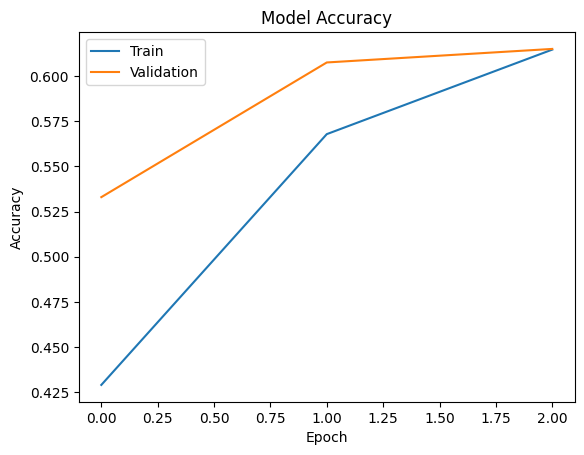

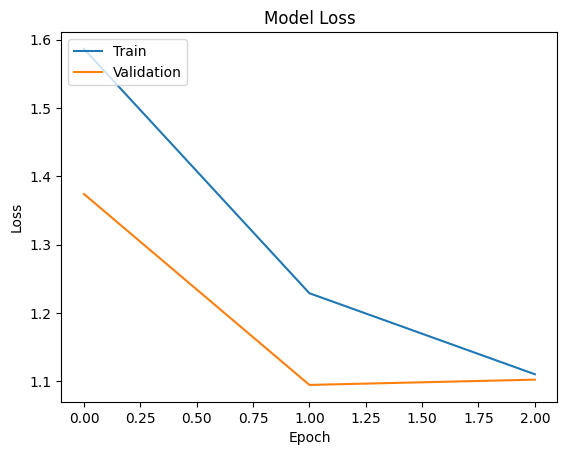

In [7]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()